In [2]:
import numpy as np

from matplotlib import pyplot as plt

plt.rcParams.update({'font.size': 14})

from monitorch.visualizer import PlayerVisualizer, MatplotlibVisualizer

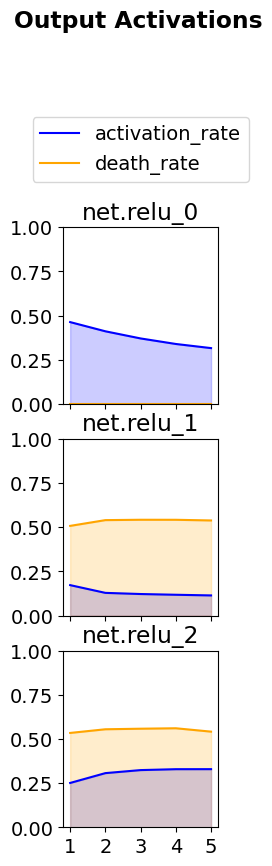

In [2]:
file = 'logs/output_activation_0.001.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
bad_to_plot = player.visualizer._to_plot

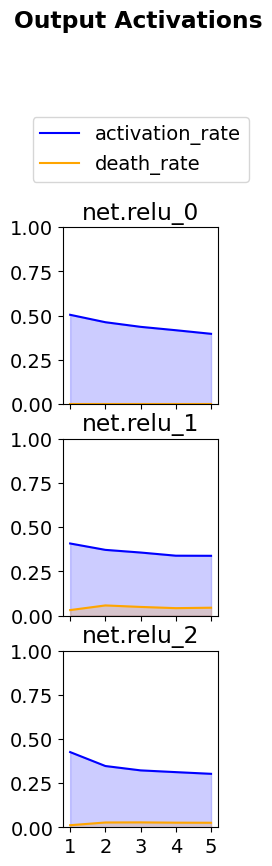

In [3]:
file = 'logs/output_activation_0.001_do05_646464.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
good_to_plot = player.visualizer._to_plot

In [4]:
bad_to_plot['Output Activations']['net.relu_1']

{'activation_rate': OrderedDict([(1, 0.17222530091814992),
              (2, 0.12832353548015768),
              (3, 0.12177692959680586),
              (4, 0.1176126704496496),
              (5, 0.11388785271998246)]),
 'death_rate': OrderedDict([(1, 0.5079124040920713),
              (2, 0.5405410805626598),
              (3, 0.542619085677749),
              (4, 0.5424592391304344),
              (5, 0.5386728740409213)])}

In [5]:
MatplotlibVisualizer._RANGE_COLORS

{('min', 'max'): 'grey',
 ('Q1', 'Q3'): 'blue',
 ('-σ', '+σ'): 'steelblue',
 ('train_loss min', 'train_loss max'): 'grey',
 ('train_loss Q1', 'train_loss Q3'): 'blue',
 ('train_loss -σ', 'train_loss +σ'): 'steelblue',
 ('val_loss min', 'val_loss max'): 'bisque',
 ('val_loss Q1', 'val_loss Q3'): 'orange',
 ('val_loss -σ', 'val_loss +σ'): 'sandybrown'}

In [6]:
def replot_death_activation_rates(rates_dict, *, ax, fig_kwargs={}, ax_title=None):
    epochs, activation_rates = rates_dict['activation_rate'].keys(), rates_dict['activation_rate'].values()
    death_rates = rates_dict['death_rate'].values()
    ax.set_ylim(0, 1)
    ax.fill_between(epochs, activation_rates, color=MatplotlibVisualizer._LINE_COLORS['activation_rate'], alpha=MatplotlibVisualizer._RANGE_ALPHA)
    ax.fill_between(epochs, death_rates, color=MatplotlibVisualizer._LINE_COLORS['death_rate'], alpha=MatplotlibVisualizer._RANGE_ALPHA)
    ax.plot(epochs, activation_rates, c=MatplotlibVisualizer._LINE_COLORS['activation_rate'], label='activation rate')
    ax.plot(epochs, death_rates, c=MatplotlibVisualizer._LINE_COLORS['death_rate'], label='death rate')
    ax.legend()
    if ax_title is not None:
        ax.set_title(ax_title)

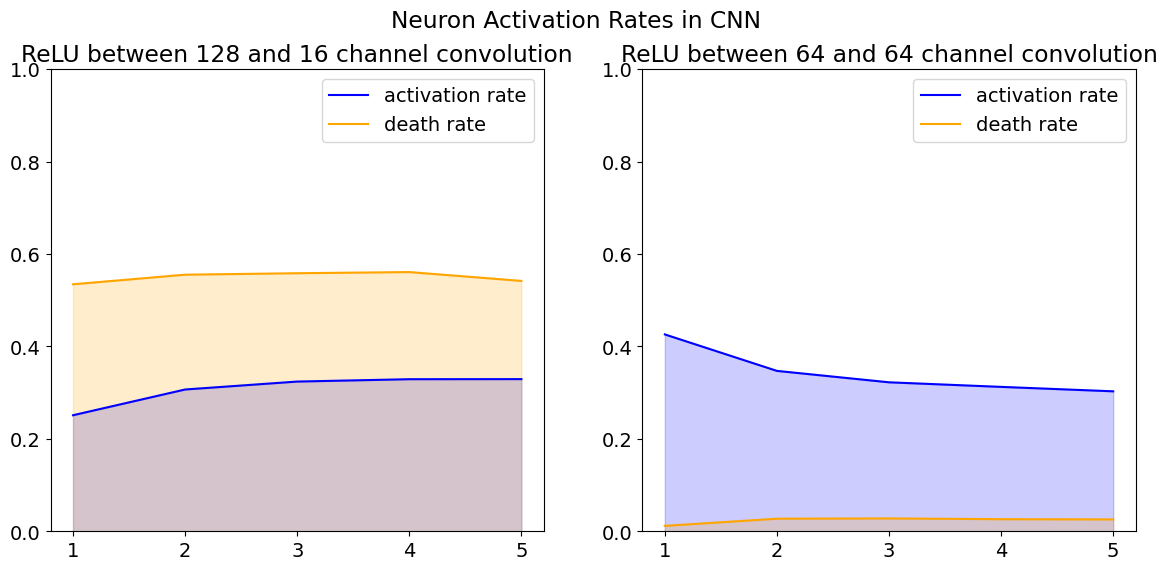

In [7]:
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(14, 6))
fig.suptitle('Neuron Activation Rates in CNN')
replot_death_activation_rates(
    bad_to_plot['Output Activations']['net.relu_2'],
    ax=ax1,
    ax_title='ReLU between 128 and 16 channel convolution',
)
ax1.set_xticks([1, 2, 3, 4, 5])
replot_death_activation_rates(
    good_to_plot['Output Activations']['net.relu_2'],
    ax=ax2,
    ax_title='ReLU between 64 and 64 channel convolution',
) 
ax2.set_xticks([1, 2, 3, 4, 5])

fig.savefig('figs/activation_comparison.pdf')

# Losses

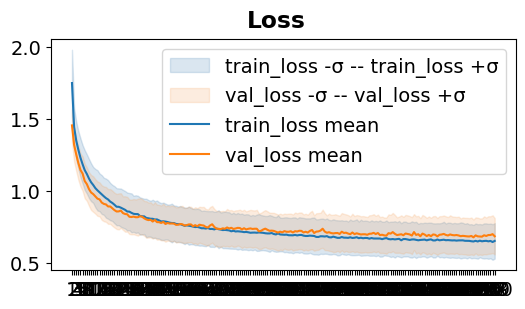

In [8]:
file = 'logs/losses_long.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
bad_to_plot = player.visualizer._to_plot

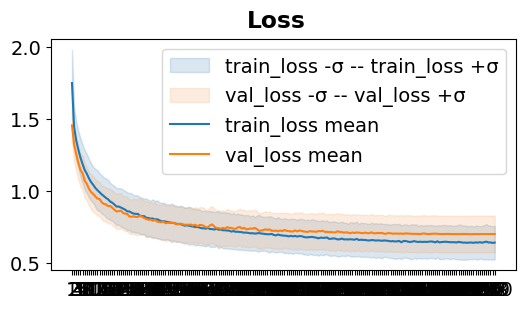

In [9]:
file = 'logs/losses_long_cosine_decay.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
good_to_plot = player.visualizer._to_plot

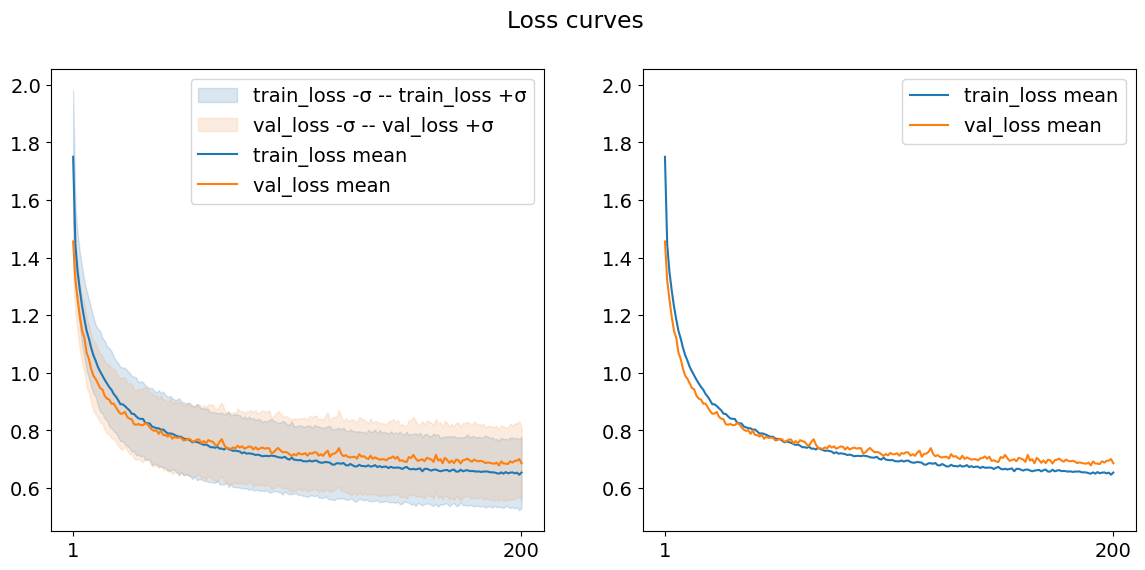

In [10]:
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(14, 6))
L = 200
ax1.set_title('')
vals, ranges = bad_to_plot['Loss']['Loss']
MatplotlibVisualizer._plot_numerical(ax1, vals, ranges)
ax1.set_xticks([1, L])
ax1.legend()

MatplotlibVisualizer._plot_numerical(ax2, vals, {})
ax2.legend()
ax2.set_ylim(*ax1.get_ylim())
ax2.set_xticks([1, L])

fig.suptitle('Loss curves')
fig.savefig('figs/loss_curves.pdf')

# output norm

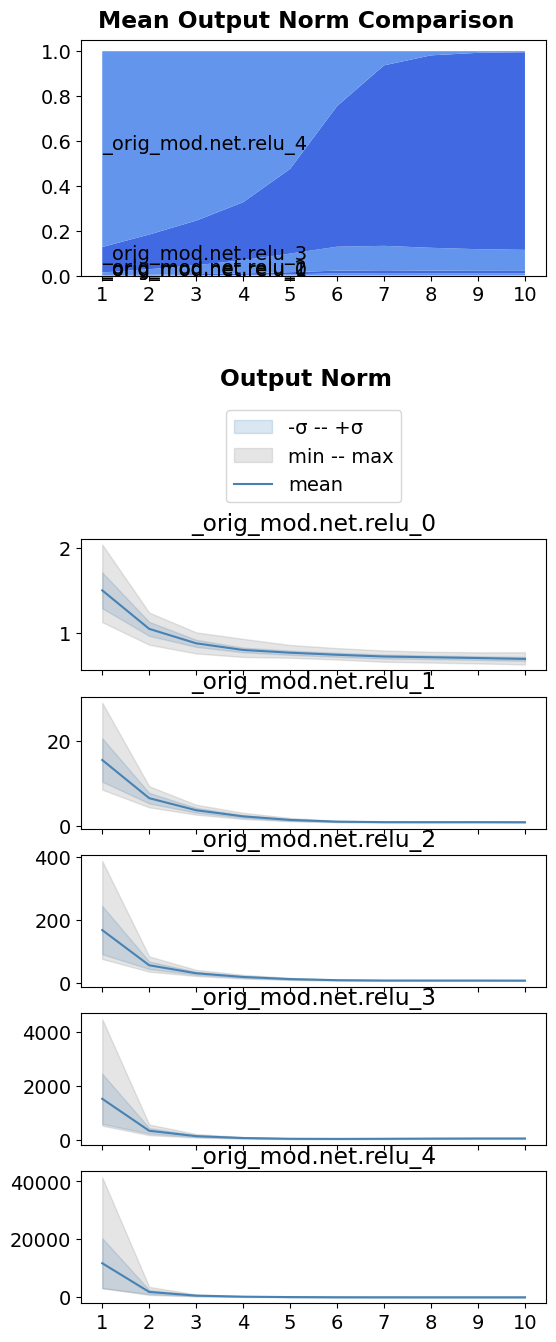

In [5]:
file = 'logs/output_norm_unif.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
bad_to_plot = player.visualizer._to_plot

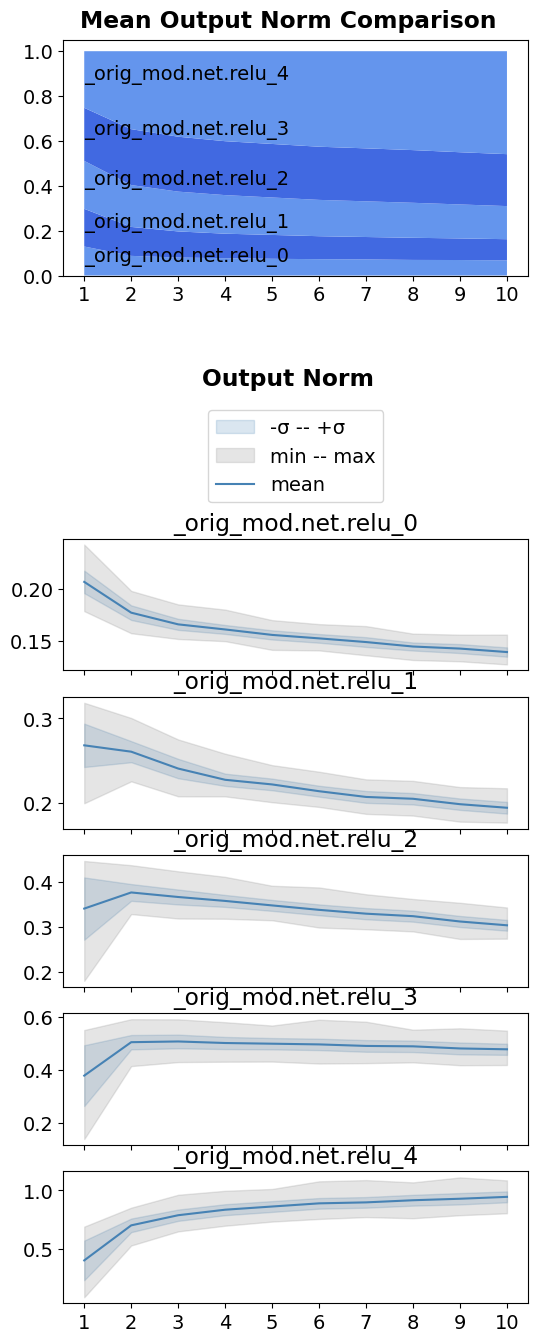

In [6]:
file = 'logs/output_norm_xavier.pkl'

player = PlayerVisualizer(file, MatplotlibVisualizer()).playback()
fig = player.visualizer.show_fig()
good_to_plot = player.visualizer._to_plot

In [8]:
bad_to_plot['Mean Output Norm Comparison']['Mean Output Norm Comparison']

OrderedDict([('_orig_mod.net.relu_0',
              OrderedDict([(1, 0.00011175128760082703),
                           (2, 0.0004674195836956049),
                           (3, 0.0011693058839516574),
                           (4, 0.0025730162813253515),
                           (5, 0.0054827280064615935),
                           (6, 0.009694489792920877),
                           (7, 0.0110569338682026),
                           (8, 0.010333535092123822),
                           (9, 0.00968601005380082),
                           (10, 0.009615338759068455)])),
             ('_orig_mod.net.relu_1',
              OrderedDict([(1, 0.0011491170068377075),
                           (2, 0.002873441571260489),
                           (3, 0.004799520311333008),
                           (4, 0.006951803679976376),
                           (5, 0.009493134467967127),
                           (6, 0.012010900956692959),
                           (7, 0.01231885582542119),

In [13]:
from collections import OrderedDict

def transform_rel_dict(d) -> OrderedDict:
    ret = OrderedDict()
    for name, subdict in d.items():
        ret[name[len('_orig_mod.'):]] = subdict
    return ret
    

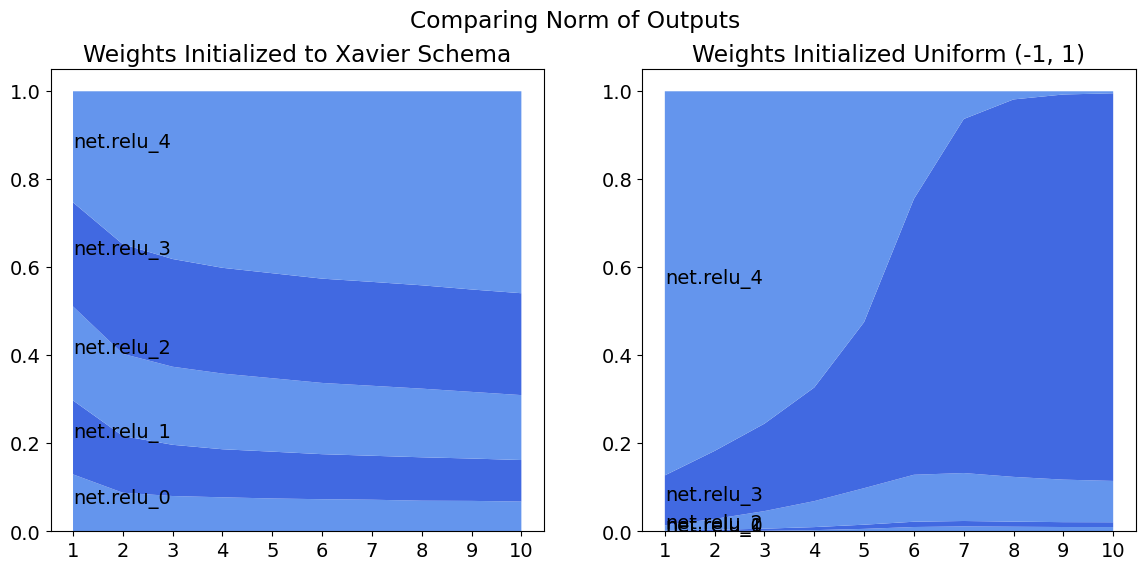

In [20]:
fig, [ax1, ax2] = plt.subplots(ncols=2, figsize=(14, 6))

fig.suptitle('Comparing Norm of Outputs')
ax1.set_title('Weights Initialized to Xavier Schema')
ret = transform_rel_dict(good_to_plot['Mean Output Norm Comparison']['Mean Output Norm Comparison'])
MatplotlibVisualizer._plot_relations(ax1, ret)

ax2.set_title('Weights Initialized Uniform (-1, 1)')
ret = transform_rel_dict(bad_to_plot['Mean Output Norm Comparison']['Mean Output Norm Comparison'])
MatplotlibVisualizer._plot_relations(ax2, ret)
fig.savefig('figs/output_comparison.pdf')